In [ ]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
import glob
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

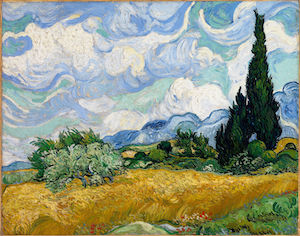

In [3]:
display(REFERENCE_IMAGE)

In [4]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [6]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    # if save_progress and time["num-generations"] % 50 == 0:
        # elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.population_size}_{evo.num_points}_{evo.generation_budget}_{evo.selection_name}_{evo.num_features_mutation_strength} {time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget, selection_name, num_features_mutation_strength = settings
    start = time()
    
    data = []
    evo = Evolution(num_points,
                    REFERENCE_IMAGE,
                    population_size=population_size,
                    generation_reporter=reporter,
                    crossover_method=crossover_method,
                    seed=seed,
                    initialization=initialization,
                    generation_budget=generation_budget,
                    num_features_mutation_strength=num_features_mutation_strength,
                    selection_name=selection_name,
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: run {seed} - pop {population_size} - num. points {num_points} - tournament size {selection_name.split('_')[1]} - mutation strength {num_features_mutation_strength} in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [9]:
%%time
data = run_algorithm((0, 100, "ONE_POINT", 100, 'RANDOM', 500, 'tournament_25', 0.25))

generation: 1 best fitness: 134707 avg. fitness: 132380.55
generation: 2 best fitness: 129944 avg. fitness: 73101.11
generation: 3 best fitness: 124087 avg. fitness: 0.0
generation: 4 best fitness: 124087 avg. fitness: 0.0
generation: 5 best fitness: 124087 avg. fitness: 0.0
generation: 6 best fitness: 124087 avg. fitness: 0.0
generation: 7 best fitness: 124087 avg. fitness: 0.0
generation: 8 best fitness: 124087 avg. fitness: 0.0
generation: 9 best fitness: 124087 avg. fitness: 0.0
generation: 10 best fitness: 124087 avg. fitness: 0.0
generation: 11 best fitness: 124087 avg. fitness: 0.0
generation: 12 best fitness: 124087 avg. fitness: 0.0
generation: 13 best fitness: 124087 avg. fitness: 0.0
generation: 14 best fitness: 124087 avg. fitness: 0.0
generation: 15 best fitness: 124087 avg. fitness: 0.0
generation: 16 best fitness: 124087 avg. fitness: 0.0
generation: 17 best fitness: 124087 avg. fitness: 0.0
generation: 18 best fitness: 124087 avg. fitness: 0.0
generation: 19 best fitnes

Process ForkPoolWorker-347:
Process ForkPoolWorker-345:
Process ForkPoolWorker-346:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):


KeyboardInterrupt: 

## Running a sweep of tournament sizes

In [26]:
%%time

generation_budget = 500
data = []

for seed_group_start in range(11, 40, 5):
    seed_group_end = min(seed_group_start + 4, 39)
    data = []
    
    for seed in range(seed_group_start, seed_group_end + 1):
        for population_size in (100,):
            for crossover_method in ("ONE_POINT",):
                for initialization in ("RANDOM",):
                    for num_points in (100,):
                        for tournament_size in ('4', '5', '10', '20', '25', '50', '100'):
                            selection_name = 'tournament_' + tournament_size
                            results = run_algorithm((
                                seed,
                                population_size,
                                crossover_method,
                                num_points,
                                initialization,
                                generation_budget,
                                selection_name,
                                0.25
                            ))
                            
                            for result in results:
                                result['selection_name'] = selection_name
                            
                            data.extend(results)

    df = pd.DataFrame(data)
    filename = f'tournament_sizes_results_seeds_{seed_group_start}_till_{seed_group_end}.csv'
    df.to_csv(filename, index=False)




generation: 1 best fitness: 139123 avg. fitness: 145060.11
generation: 2 best fitness: 131997 avg. fitness: 140081.8
generation: 3 best fitness: 129664 avg. fitness: 136219.32
generation: 4 best fitness: 126679 avg. fitness: 132650.97
generation: 5 best fitness: 124471 avg. fitness: 129819.42
generation: 6 best fitness: 124471 avg. fitness: 127716.89


KeyboardInterrupt: 

## Running different num_features_mutation_strength for tournament size 20

In [ ]:
%%time

generation_budget = 500
data = []

# Modified this to run for multiple mutation parameters
for seed in range(27, 40):
    for population_size in (100,):
        for crossover_method in ("ONE_POINT",):
            for initialization in ("RANDOM",):
                for num_points in (100,):
                    for num_features_mutation_strength in (0.75,):
                        selection_name = 'tournament_20'
                        results = run_algorithm((
                            seed,
                            population_size,
                            crossover_method,
                            num_points,
                            initialization,
                            generation_budget,
                            selection_name,
                            num_features_mutation_strength,
                            
                        ))
                        
                        for result in results:
                            result['selection_name'] = selection_name
                            result['num_features_mutation_strength'] = num_features_mutation_strength
                        data.extend(results)

    df = pd.DataFrame(data)
    filename = f'tournament_20_results_seed_{seed}_mutation_check.csv'
    df.to_csv(filename, index=False)

Process ForkPoolWorker-113:
Process ForkPoolWorker-115:
Process ForkPoolWorker-114:
Process ForkPoolWorker-116:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/sofie/.pyenv/versions/ea-env1/lib/python3.10/site-packages/multiprocess/process.py", line 315, in _bootstrap
    self.run()
  File "/home/sofie/.pyenv/versions/ea-env1/lib/python3.10/site-packages/multiprocess/process.py", line 315, in _bootstrap
    self.run()
  File "/home/sofie/.pyenv/versions/ea-env1/lib/python3.10/site-packages/multiprocess/process.py", line 315, in _bootstrap
    self.run()
  File "/home/sofie/.pyenv/versions/ea-env1/lib/python3.10/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/sofie/.pyenv/versions/ea-env1/lib/python3.10/site-packages/multiprocess/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/sofie/.pyenv/versions/ea-env1/l

## Check which mutation_strength is best

In [6]:
mutation_strengths = [0.25, 0.5, 0.75, 1]
results = {strength: [] for strength in mutation_strengths}

for seed in range(40):
    filename = f'csv_files_tournament_sizes/tournament_20_results_seed_{seed}_mutation_check.csv'
    try:
        df = pd.read_csv(filename)
        
        last_gens = df.groupby('num_features_mutation_strength').last().reset_index()
        
        for _, row in last_gens.iterrows():
            strength = row['num_features_mutation_strength']
            avg_fitness = row['avg-fitness']
            results[strength].append(avg_fitness)
            
    except FileNotFoundError:
        print(f"File {filename} not found")

avg_fitness_per_strength = {}

for strength, fitness_values in results.items():
    avg_fitness = np.mean(fitness_values)
    num_seeds = len(fitness_values)
    
    avg_fitness_per_strength[strength] = {
        'avg-fitness-last-gen': avg_fitness,
        'num_seed': num_seeds
    }

for strength, data in avg_fitness_per_strength.items():
    print(f"mut strength: {strength}, avg fitness: {data['avg-fitness-last-gen']}, seeds: {data['num_seed']}")

mut strength: 0.25, avg fitness: 40371.966, seeds: 10
mut strength: 0.5, avg fitness: 36161.63049999999, seeds: 20
mut strength: 0.75, avg fitness: 35979.210750000006, seeds: 40
mut strength: 1, avg fitness: 36715.9625, seeds: 20


## Plot avg fitness vs generations

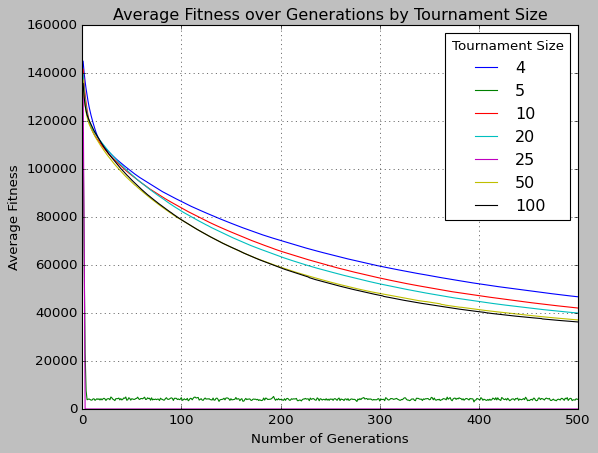

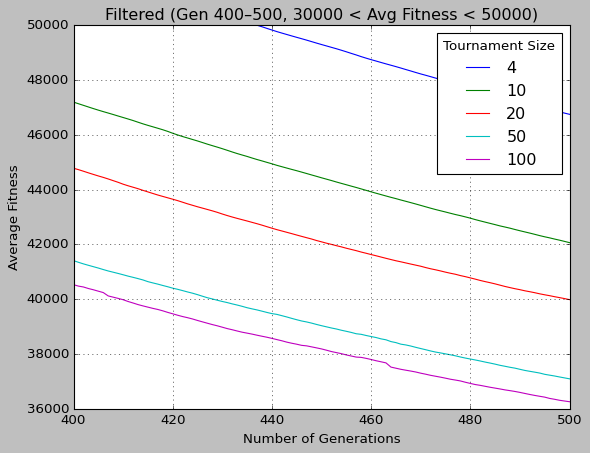

In [12]:
import glob
csv_files = glob.glob("csv_files_tournament_sizes/tournament_sizes_results_seeds_*.csv")
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list)


grouped = df.groupby(['selection_name', 'num-generations'])['avg-fitness'].mean().reset_index()

def plot_avg_fitness(data, title, y_label):
    for selection_name in sorted(data['selection_name'].unique(), key=lambda x: int(x.split('_')[1])):
        subset = data[data['selection_name'] == selection_name]
        plt.plot(subset['num-generations'], subset['avg-fitness'], label=selection_name.split('_')[1])
    plt.xlabel('Number of Generations')
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(title='Tournament Size')
    plt.grid(True)
    plt.show()

plot_avg_fitness(grouped, 'Average Fitness over Generations by Tournament Size', 'Average Fitness')

filtered = grouped[(grouped['num-generations'] >= 400) & 
                   (grouped['num-generations'] <= 500) & 
                   (grouped['avg-fitness'] < 50000) &
                   (30000 < grouped['avg-fitness'])]

plot_avg_fitness(filtered, 'Filtered (Gen 400–500, 30000 < Avg Fitness < 50000)', 'Average Fitness')


## Plots of premature convergence

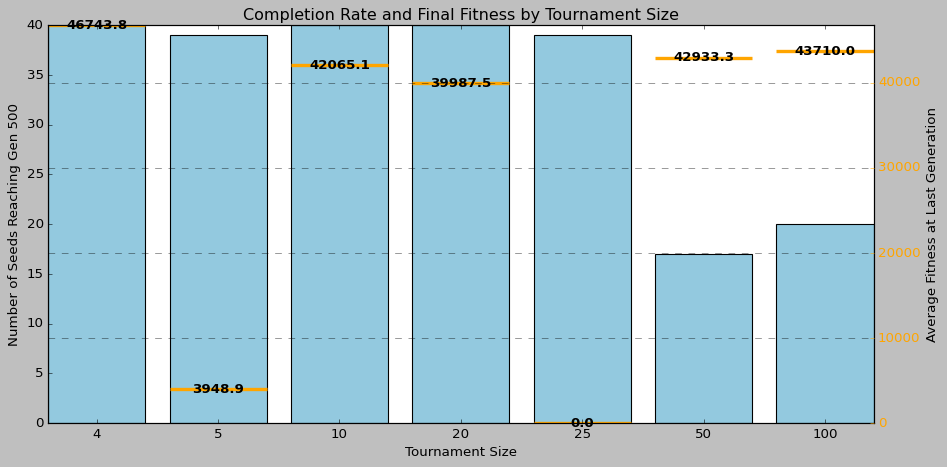

In [ ]:
#NOTE: used chatgpt to make this plot
import glob
csv_files = glob.glob("csv_files_tournament_sizes/tournament_sizes_results_seeds_*.csv")
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

df['tournament_size'] = df['selection_name'].str.extract('_(\d+)').astype(int)

# Calculate completion status (whether each seed reached gen 500)
completion_status = (
    df.groupby(['tournament_size', 'seed'])['num-generations']
    .max()
    .reset_index()
)
completion_status['reached_500'] = completion_status['num-generations'] >= 500

# Get fitness at last generation for each seed
last_gen_fitness = (
    df.sort_values(['tournament_size', 'seed', 'num-generations'])
    .groupby(['tournament_size', 'seed'])
    .last()
    .reset_index()
)

summary = (
    completion_status.groupby('tournament_size')
    .agg(
        total_seeds=('seed', 'count'),
        seeds_reaching_500=('reached_500', 'sum')
    )
    .reset_index()
)

fitness_summary = (
    last_gen_fitness.groupby('tournament_size')['avg-fitness']
    .mean()
    .reset_index()
    .rename(columns={'avg-fitness': 'avg_fitness_last_gen'})
)
summary = pd.merge(summary, fitness_summary, on='tournament_size')

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=summary,
    x='tournament_size',
    y='seeds_reaching_500',
    color='skyblue',
)

max_completed = summary['seeds_reaching_500'].max()
max_fitness = summary['avg_fitness_last_gen'].max()
scale_factor = max_completed / max_fitness if max_fitness > 0 else 1

for i, row in summary.iterrows():
    if row['avg_fitness_last_gen'] >= 0:
        ax.hlines(
            row['avg_fitness_last_gen'] * scale_factor,
            i - 0.4,
            i + 0.4,
            color='orange',
            linewidth=3,
            label='Avg Fitness' if i == 0 else ""
        )
        ax.text(
            i,
            row['avg_fitness_last_gen'] * scale_factor,
            f"{row['avg_fitness_last_gen']:.1f}",
            ha='center',
            va='center',
            color='black',
            fontweight='bold'
        )

# Add secondary axis for fitness
if max_fitness > 0:
    ax2 = ax.twinx()
    ax2.set_ylim(0, max_fitness)
    ax2.set_ylabel('Average Fitness at Last Generation', color='black')
    ax2.tick_params(axis='y', colors='orange')

ax.set_xlabel('Tournament Size')
ax.set_ylabel('Number of Seeds Reaching Gen 500')
plt.title('Completion Rate and Final Fitness by Tournament Size')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## Plots of time for tournament sizes 4, 10 and 20

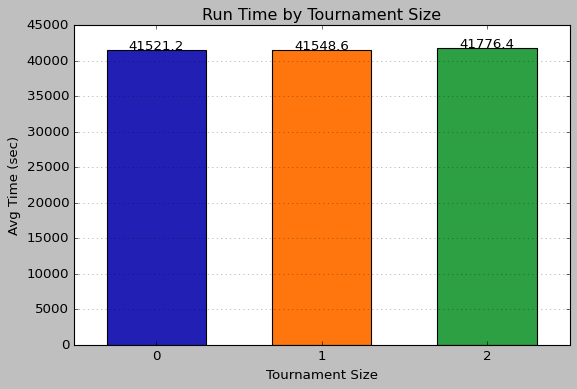

In [21]:
# NOTE: tournament size 5 and 25 images are very bad (even though their fitness is good?)

df['tournament_size'] = df['selection_name'].str.extract('_(\d+)').astype(int)
sizes = [4, 10, 20]
filtered = df[df['tournament_size'].isin(sizes)]

time_data = filtered.groupby(['tournament_size', 'seed'])['time-elapsed'].sum().reset_index()
avg_times = time_data.groupby('tournament_size')['time-elapsed'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8,5))
colors = ["#211fb4", "#ff760e", "#2ca043"]  # Basic colors
for i, size in enumerate(avg_times['tournament_size']):
    time = avg_times.loc[avg_times['tournament_size'] == size, 'time-elapsed'].values[0]
    ax.bar(i, time, color=colors[i], width=0.6)
    ax.text(i, time+0.5, f'{time:.1f}', ha='center')
ax.set_xticks(range(len(sizes)))
ax.set_xlabel('Tournament Size')
ax.set_ylabel('Avg Time (sec)')
ax.set_title('Run Time by Tournament Size')

ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.show()

## Displaying the best instances over time

In [7]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, generation_budget + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_{generation_budget}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './img/van_gogh_intermediate_0_100_ONE_POINT_100_500_00050.png'

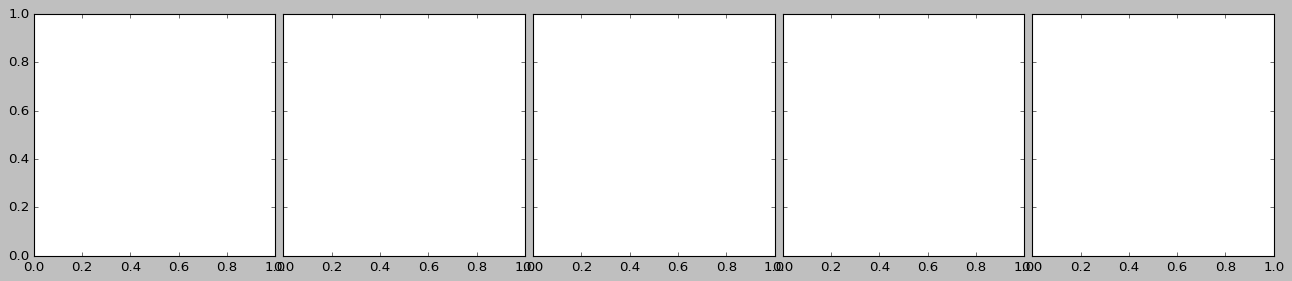

In [ ]:
show_progress_over_time((0, 100, 'ONE_POINT', 100, 500), grid=(1,5))